# Attention Analysis

In [ ]:
!pip -q install transformers accelerate

import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "gpt2"  # good baseline
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager"
).to(device)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
def extract_new_token_attention_across_layers(outputs):
    """
    outputs.attentions: tuple length n_layers
      each element: (batch, n_heads, q_len, k_len)
    With cache + step-by-step, q_len is often 1 (new token only).
    We average heads and return (n_layers, k_len) for the new token.
    """
    attn_layers = outputs.attentions
    n_layers = len(attn_layers)
    seq_len = attn_layers[0].shape[-1]

    layer_rows = []
    for l in range(n_layers):
        attn = attn_layers[l]              # (1, heads, q_len, k_len)
        row = attn[0, :, -1, :]            # (heads, k_len)  (-1 works for both q_len=1 or >1)
        row_mean = row.mean(dim=0)         # (k_len,)
        layer_rows.append(row_mean.detach().cpu().float().numpy())

    return np.stack(layer_rows, axis=0)    # (n_layers, seq_len)

In [ ]:
def extract_new_token_delta_norm_across_layers(outputs):
    """
    outputs.hidden_states: tuple length n_layers + 1
      hidden_states[l]: (batch, seq_len, d_model)
    We'll compute ||h_{l+1} - h_l|| for the newest token position.
    Returns shape (n_layers,)
    """
    hs = outputs.hidden_states
    n_layers = len(hs) - 1

    deltas = []
    for l in range(n_layers):
        h_l   = hs[l][0, -1, :]      # newest token
        h_lp1 = hs[l+1][0, -1, :]
        delta = (h_lp1 - h_l).norm().detach().cpu().float().item()
        deltas.append(delta)

    return np.array(deltas)          # (n_layers,)

In [ ]:
def attention_entropy(attn_row, eps=1e-12):
    """
    attn_row: (seq_len,) numpy, sums to 1
    Returns scalar entropy.
    """
    p = np.clip(attn_row, eps, 1.0)
    return float(-(p * np.log(p)).sum())

def extract_entropy_across_layers(attn_matrix):
    """
    attn_matrix: (n_layers, seq_len)
    """
    return np.array([attention_entropy(attn_matrix[l]) for l in range(attn_matrix.shape[0])])

In [ ]:
prompt = "In a quiet village, the old clocktower"
max_new_tokens = 25

input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

# We'll store per-step scan data
attn_scans = []     # list of (n_layers, seq_len_at_step)
delta_scans = []    # list of (n_layers,)
entropy_scans = []  # list of (n_layers,)
decoded_tokens = []

with torch.no_grad():
    for step in range(max_new_tokens):
        outputs = model(
            input_ids=input_ids,
            use_cache=True,
            output_attentions=True,
            output_hidden_states=True,
            return_dict=True
        )

        # next token (greedy for now; you can sample later)
        next_token_id = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)

        # collect brainscan for THIS step's newest position (the last position in input_ids)
        attn_mat = extract_new_token_attention_across_layers(outputs)         # (layers, seq_len)
        deltas = extract_new_token_delta_norm_across_layers(outputs)          # (layers,)
        ents = extract_entropy_across_layers(attn_mat)                        # (layers,)

        attn_scans.append(attn_mat)
        delta_scans.append(deltas)
        entropy_scans.append(ents)

        # append token and continue
        input_ids = torch.cat([input_ids, next_token_id], dim=1)
        decoded_tokens.append(tokenizer.decode(next_token_id[0]))

full_text = tokenizer.decode(input_ids[0])
print(full_text)

In a quiet village, the old clocktower was still standing.

"I'm sorry, but I'm not sure if you're right. I'm not sure


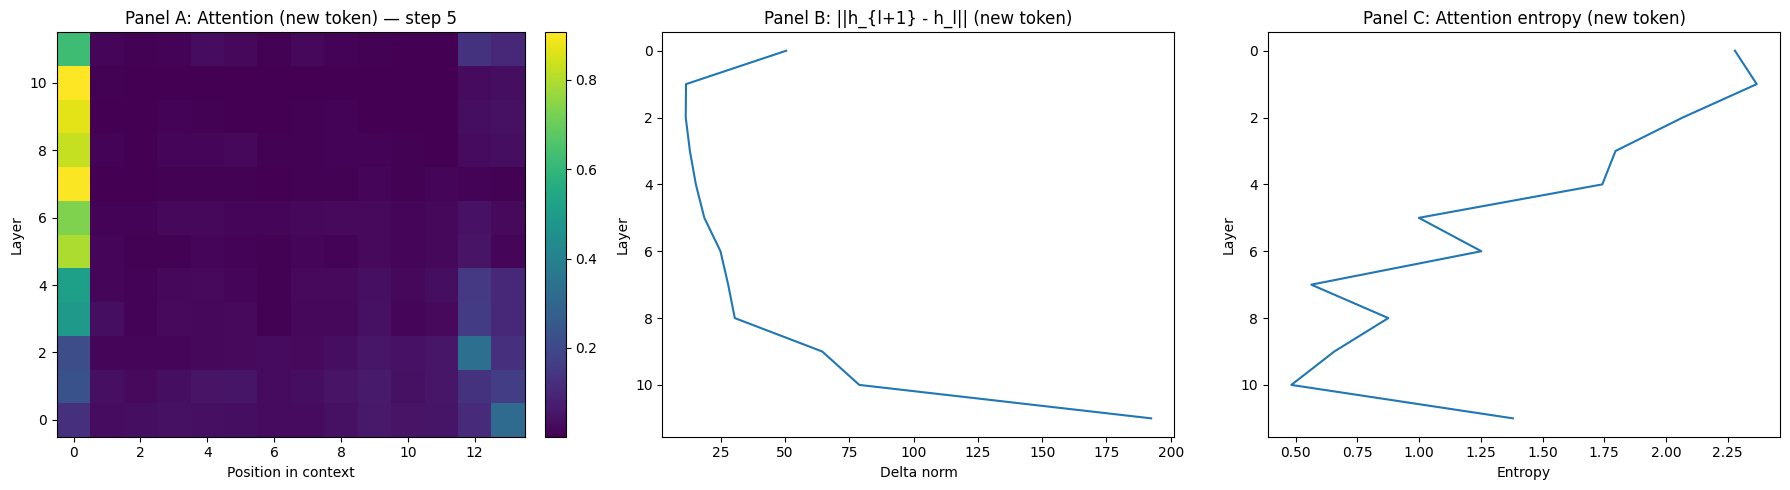

Generated token at step k: 



In [ ]:
k = 5  # pick a generation step to inspect
attn_mat = attn_scans[k]       # (layers, seq_len)
deltas = delta_scans[k]        # (layers,)
ents = entropy_scans[k]        # (layers,)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: attention heatmap (layers x positions)
im = axs[0].imshow(attn_mat, aspect="auto", origin="lower")
axs[0].set_title(f"Panel A: Attention (new token) — step {k}")
axs[0].set_xlabel("Position in context")
axs[0].set_ylabel("Layer")
plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

# Panel B: delta norm across layers
axs[1].plot(deltas, np.arange(len(deltas)))
axs[1].invert_yaxis()
axs[1].set_title("Panel B: ||h_{l+1} - h_l|| (new token)")
axs[1].set_xlabel("Delta norm")
axs[1].set_ylabel("Layer")

# Panel C: entropy across layers
axs[2].plot(ents, np.arange(len(ents)))
axs[2].invert_yaxis()
axs[2].set_title("Panel C: Attention entropy (new token)")
axs[2].set_xlabel("Entropy")
axs[2].set_ylabel("Layer")

plt.tight_layout()
plt.show()

print("Generated token at step k:", decoded_tokens[k])

In [ ]:
!pip -q install bertviz transformers

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from bertviz import head_view, model_view  # head_view is the classic

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, attn_implementation="eager").to(device)
model.eval()

text = "In a quiet village, the old clocktower"
inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True, return_dict=True)

attentions = outputs.attentions  # tuple of (1, heads, T, T) per layer
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

head_view(attentions, tokens)     # interactive per-head routing
# model_view(attentions, tokens)  # alternative UI

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<IPython.core.display.Javascript object>

In [5]:
# --- Install deps ---
!pip -q install bertviz

# --- Standard libs ---
import json
import os
import uuid

# --- Torch / utils ---
import torch
from tqdm import tqdm

# --- HF Transformers ---
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,  # sentiment
    AutoModelForCausalLM,                # text-gen
    AutoModelForQuestionAnswering,       # QA
    pipeline,
)

# --- Visualization (bertviz) ---
from bertviz import head_view, model_view

# --- Colab / environment niceties ---
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 140.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00
transformers: 5.0.0
torch: 2.10.0+cu128
device: cuda


In [8]:
# ---------- Helpers + Viz runners (DROP-IN REPLACEMENT CELL) ----------

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    AutoModelForQuestionAnswering,
    pipeline,
)

# bertviz views (installed/imported in your setup cell)
from bertviz import head_view, model_view

# Device (use torch.device from your setup if you want; this works fine too)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def format_special_chars(tokens):
    return [
        t.replace("Ġ", " ")
        .replace("▁", " ")
        .replace("</w>", "")
        .replace("ĊĊ", " ")
        .replace("Ċ", " ")
        for t in tokens
    ]


def _ensure_attentions(outputs):
    """
    Returns a tuple of attention tensors (one per layer), each shaped:
      (batch, heads, seq_len, seq_len)
    Filters out None entries and raises a clear error if nothing is available.
    """
    attentions = getattr(outputs, "attentions", None)
    if attentions is None:
        raise RuntimeError(
            "Model returned outputs.attentions=None. "
            "This model/config isn't producing attention. "
            "Make sure model.config.output_attentions=True and it's a transformer model."
        )
    attentions = tuple(a for a in attentions if a is not None)
    if len(attentions) == 0:
        raise RuntimeError("All attention layers were None. Nothing to visualize.")
    # sanity: each should be 4D
    for i, a in enumerate(attentions):
        if not hasattr(a, "shape") or len(a.shape) != 4:
            raise RuntimeError(f"Attention layer {i} has unexpected shape/value: {type(a)} {getattr(a,'shape',None)}")
    return attentions


def get_attn_for_bertviz(model, tokenizer, text_a, text_b=None, prettify_tokens=True):
    """
    Returns:
      tokens: list[str]
      attentions: tuple[tensor] length=num_layers, each (batch, heads, seq, seq)
    """
    model.to(device)
    model.eval()

    # Force attentions on (more reliable than passing output_attentions=... every call)
    model.config.output_attentions = True

    inputs = tokenizer(
        text_a,
        text_b,
        add_special_tokens=True,
        return_tensors="pt",
        return_attention_mask=True,
        truncation=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, return_dict=True)

    attentions = _ensure_attentions(outputs)

    input_ids = inputs["input_ids"][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    if prettify_tokens:
        tokens = format_special_chars(tokens)

    return tokens, attentions


# -------------------- Task runners --------------------

def text_generation_viz(prompts, model_version, max_new_tokens=20, view="head"):
    """
    Visualize GPT-style attention on the PROMPT (and optionally on generated text).
    Note: bertviz is primarily designed for encoder/bi-directional models, but it can still
    display causal LM attentions.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_version)
    model = AutoModelForCausalLM.from_pretrained(model_version, attn_implementation="eager").to(device)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

    gen_pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
    )

    for prompt in tqdm(prompts):
        out = gen_pipe(prompt, max_new_tokens=max_new_tokens, do_sample=False)[0]["generated_text"]

        # Visualize attention over the generated text (you can change to prompt if you want)
        tokens, attentions = get_attn_for_bertviz(model, tokenizer, out)

        if view == "model":
            model_view(attentions, tokens)
        else:
            head_view(attentions, tokens)


def sentiment_viz(prompts, model_version, view="head"):
    """
    Correct model: AutoModelForSequenceClassification (not CausalLM).
    """
    tokenizer = AutoTokenizer.from_pretrained(model_version)
    model = AutoModelForSequenceClassification.from_pretrained(model_version, attn_implementation="eager").to(device)

    # For many BERT-family tokenizers, pad_token exists; if not, set it safely.
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else "[PAD]"
    if getattr(model.config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    sa_pipe = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
    )

    for text in tqdm(prompts):
        pred = sa_pipe(text)[0]
        print(f"\nTEXT: {text}\nPRED: {pred}")

        tokens, attentions = get_attn_for_bertviz(model, tokenizer, text)

        if view == "model":
            model_view(attentions, tokens)
        else:
            head_view(attentions, tokens)


def qa_viz(context, prompts, model_version, view="head"):
    """
    Correct model: AutoModelForQuestionAnswering.
    Visualize attention over (question, context).
    """
    tokenizer = AutoTokenizer.from_pretrained(model_version)
    model = AutoModelForQuestionAnswering.from_pretrained(model_version, attn_implementation="eager").to(device)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else "[PAD]"
    if getattr(model.config, "pad_token_id", None) is None and tokenizer.pad_token_id is not None:
        model.config.pad_token_id = tokenizer.pad_token_id

    qa_pipe = pipeline(
        "question-answering",
        model=model,
        tokenizer=tokenizer,
        device=0 if device.type == "cuda" else -1,
    )

    for q in tqdm(prompts):
        pred = qa_pipe(question=q, context=context)
        print(f"\nQ: {q}\nA: {pred.get('answer')}\nSCORE: {pred.get('score')}")

        tokens, attentions = get_attn_for_bertviz(model, tokenizer, q, text_b=context)

        if view == "model":
            model_view(attentions, tokens)
        else:
            head_view(attentions, tokens)

In [9]:
# ---------- Experiment 1: GPT-2 text generation attention viz ----------

textgen_model_version = "gpt2"
text_gen_prompts = [
    "The animal didn't cross the street because it was too",
    "The dog didn't play at the park because it was too",
    "I went to the store. At the store I bought fresh",
    "At the store he bought flowers, candy, jewelry, and",
    "The dog ran up the street and barked too",
    "In 2016, the Young Mens' Christian Association (YMCA) was very",
    "The Doctor asked the Nurse a question. She",
    "The Doctor asked the Nurse a question. He",
]

# view="head" (interactive heads) or view="model" (overview)
text_generation_viz(
    text_gen_prompts,
    textgen_model_version,
    max_new_tokens=20,
    view="head",
)

Output hidden; open in https://colab.research.google.com to view.

In [10]:
sa_prompts = [
    "Many people dislike Steve Jobs, while acknowledging his genius.",
    "The quick, brown fox jumps over the lazy dog.",
    "It was a beautiful day.",
    "It was a horrible day.",
    "I am confused.",
    "That movie was so sick but I wish it was longer.",
    "That movie was so awesome but I wish it was longer.",
    "That movie was so gross but I wish it was longer.",
    "That movie was so available but I wish it was longer.",
]
sa_model_version = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_viz(sa_prompts, sa_model_version)

Output hidden; open in https://colab.research.google.com to view.

In [11]:
context = r"""A robot may not injure a human being or, through inaction, allow a human being to come to harm.
A robot must obey the orders given it by human beings except where such orders would conflict with the First Law.
A robot must protect its own existence as long as such protection does not conflict with the First or Second Laws.
"""
questions = [
    "Can a robot hurt a human?",
    "Can a robot injure a human?",
    "Should a robot obey orders from humans?",
    "Can a robot protect itself from a human?",
    "Can a robot love a human?"
]

qa_viz(context, questions, "distilbert-base-uncased-distilled-squad")

Output hidden; open in https://colab.research.google.com to view.

In [41]:
!pip -q install transformers accelerate ipywidgets

import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
import ipywidgets as widgets
from IPython.display import display

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    attn_implementation="eager"   # ensures attention weights are materialized
).to(device)

tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [52]:
prompt = (
    "In a quiet village, the old clocktower had not chimed in years. "
    "Tonight, a stranger arrived with a key and a warning. "
)

enc = tokenizer(prompt, return_tensors="pt", padding=False)
input_ids = enc["input_ids"].to(device)
attention_mask = enc["attention_mask"].to(device)

with torch.no_grad():
    gen = model.generate(
        input_ids=input_ids,
        attention_mask=attention_mask,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.9,
        top_p=0.92,
        top_k=50,
        repetition_penalty=1.1,
        no_repeat_ngram_size=3,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

full_ids = gen[0]
tokens = tokenizer.convert_ids_to_tokens(full_ids)
print(tokenizer.decode(full_ids))
T = len(tokens)
print("Total tokens:", T)

In a quiet village, the old clocktower had not chimed in years. Tonight, a stranger arrived with a key and a warning.  "We are coming here!" he shouted angrily before leaping into his car to avoid detection from some of the guards surrounding him.
The security guard rushed over and put on their balaclavas as they drove away at quick speed through thick woods near town. Two dozen people were already outside when
Total tokens: 89


In [44]:
import math
import torch

captures = {}

def split_heads(x, num_heads, head_dim):
    # x: (B, T, d_model) where d_model = num_heads * head_dim
    B, T, D = x.shape
    x = x.view(B, T, num_heads, head_dim)      # (B, T, H, Dh)
    return x.permute(0, 2, 1, 3)               # (B, H, T, Dh)

def make_attn_hook(layer_idx):
    def hook(module, inputs, outputs):
        hidden_states = inputs[0]  # (B, T, d_model)
        B, T, d_model = hidden_states.shape

        # QKV projection (GPT-2 packs them together)
        qkv = module.c_attn(hidden_states)     # (B, T, 3*d_model)
        q, k, v = qkv.split(d_model, dim=2)    # each (B, T, d_model)

        # Split into heads
        H = module.num_heads
        Dh = d_model // H
        q = split_heads(q, H, Dh)              # (B, H, T, Dh)
        k = split_heads(k, H, Dh)
        v = split_heads(v, H, Dh)

        # Raw scores (pre-softmax)
        scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(Dh)  # (B,H,T,T)

        # Causal mask: GPT-2 has a precomputed triangular bias buffer
        # module.bias shape is typically (1,1,max_positions,max_positions)
        causal = module.bias[:, :, :T, :T]  # (1,1,T,T), 1 where allowed
        scores = scores.masked_fill(causal == 0, float("-inf"))

        # Softmax weights
        weights = torch.softmax(scores, dim=-1)  # (B,H,T,T)

        # Value mixing
        z = torch.matmul(weights, v)             # (B,H,T,Dh)

        captures[layer_idx] = {
            "scores":  scores[0].detach().cpu(),   # (H,T,T)
            "weights": weights[0].detach().cpu(),  # (H,T,T)
            "z":       z[0].detach().cpu(),        # (H,T,Dh)
        }
    return hook

    hooks = []
for l, block in enumerate(model.transformer.h):
    hooks.append(block.attn.register_forward_hook(make_attn_hook(l)))

In [45]:
with torch.no_grad():
    _ = model(full_ids.unsqueeze(0).to(device), return_dict=True)

for h in hooks:
    h.remove()

print("Captured layers:", sorted(captures.keys()))
print("Example shapes (layer 0):",
      captures[0]["scores"].shape,
      captures[0]["weights"].shape,
      captures[0]["z"].shape)

Captured layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Example shapes (layer 0): torch.Size([12, 89, 89]) torch.Size([12, 89, 89]) torch.Size([12, 89, 64])


In [46]:
def plot_brainscan_for_token(layer, token_idx):
    data = captures[layer]
    scores = data["scores"]    # (H, T, T)
    weights = data["weights"]  # (H, T, T)
    z = data["z"]              # (H, T, Dh)

    H = scores.shape[0]
    T = scores.shape[-1]

    # Extract the ROW for this token: shape (H, T)
    s_row = scores[:, token_idx, :].numpy()
    w_row = weights[:, token_idx, :].numpy()

    # Attention output per head for this token: (H, Dh) → norm per head
    z_tok = z[:, token_idx, :].numpy()
    z_norm = np.linalg.norm(z_tok, axis=-1)

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))

    # Scores heatmap
    im0 = axs[0].imshow(s_row, aspect="auto", origin="lower")
    axs[0].set_title(f"Layer {layer} | Token {token_idx}: '{tokens[token_idx]}'\nScores QKᵀ (pre-softmax) per head")
    axs[0].set_xlabel("Key position j")
    axs[0].set_ylabel("Head")
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    # Weights heatmap
    im1 = axs[1].imshow(w_row, aspect="auto", origin="lower", vmin=0.0, vmax=w_row.max() if w_row.max() > 0 else 1.0)
    axs[1].set_title("Attention weights softmax(scores) per head")
    axs[1].set_xlabel("Key position j")
    axs[1].set_ylabel("Head")
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    # Z norm bar
    axs[2].bar(np.arange(H), z_norm)
    axs[2].set_title("Attention readout strength per head\n||Z_i|| where Z = weights @ V")
    axs[2].set_xlabel("Head")
    axs[2].set_ylabel("||Z_i||")

    plt.tight_layout()
    plt.show()

    # Helpful: print the prefix so you know context
    prefix = tokenizer.decode(full_ids[:token_idx+1])
    print("Context up to token:", token_idx)
    print(prefix)

In [53]:
layer_slider = widgets.IntSlider(value=0, min=0, max=len(model.transformer.h)-1, step=1, description="Layer")
token_slider = widgets.IntSlider(value=min(10, T-1), min=0, max=T-1, step=1, description="Token i")

ui = widgets.VBox([layer_slider, token_slider])
out = widgets.interactive_output(plot_brainscan_for_token, {"layer": layer_slider, "token_idx": token_slider})
display(ui, out)

Output()